In [1]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import random
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm import tqdm
import torchvision.transforms.functional as TF
from torch.amp import GradScaler, autocast
import matplotlib.pyplot as plt
import json
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [2]:
# ==========================================
# 1. HARDWARE & PATH CONFIGURATION
# ==========================================
DEVICE = torch.device("cuda")

OIL_DIR = "../data/oil_images_preprocessed/"
BACK_DIR = "../data/background_preprocessed/"

OIL_MASK_SUB = "oil_masks"
OIL_IMG_SUB  = "oil_images"
BACK_MASK_SUB = "masks"
BACK_IMG_SUB  = "images"

MODEL_SAVE_PATH = "m3_t2_best_oil_spill_model.pth"

In [3]:
# ==========================================
# 2. DATASET CLASS WITH FIXES
# ==========================================

train_transform = A.Compose([
    # 1. Spatial robustness (Corrected 'size' for Albumentations 2.x)
    A.RandomResizedCrop(size=(256, 256), scale=(0.7, 1.0), p=1.0),
    
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),

    # 2. Geometric distortion 
     A.Affine(
    translate_percent={"x": (-0.05, 0.05), "y": (-0.05, 0.05)},
    scale=(0.9, 1.1),
    rotate=(-15, 15),
    border_mode=0,
    p=0.4
    ),

    # 3. Sensor noise simulation 
    A.OneOf([
        A.GaussNoise(std_range=(0.01, 0.02), p=1.0),
        A.MultiplicativeNoise(multiplier=(0.9, 1.1), p=1.0),
    ], p=0.3),

    # 4. Illumination variation
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.3),

    # 5. Missing sensor pixels simulation (CoarseDropout)
    A.CoarseDropout(
        num_holes_range=(1, 3), 
        hole_height_range=(0.05, 0.1), 
        hole_width_range=(0.05, 0.1), 
        fill=0, 
        p=0.2
    ),

    ToTensorV2(),
])

val_transform = A.Compose([
    ToTensorV2(), # No crops, no noise, just convert to Tensor
])

class OilSpillDataset(Dataset):
    def __init__(self, oil_dir, back_dir, augment=True,transform=None):
        
        # 1. Get all paths
        oil_images_all = sorted(glob.glob(os.path.join(OIL_DIR, OIL_IMG_SUB, "*.npy")))
        back_images_all = sorted(glob.glob(os.path.join(BACK_DIR, BACK_IMG_SUB, "*.npy")))
        
        # 2. RANDOM SAMPLING (Fixes variety: mix of look-alikes and empty ocean)
        # We take 6000 random samples from each to balance the classes
        self.oil_images = random.sample(oil_images_all, min(6000, len(oil_images_all)))
        self.back_images = random.sample(back_images_all, min(6000, len(back_images_all)))
        
        self.oil_mask_dir = os.path.join(OIL_DIR, OIL_MASK_SUB)
        self.back_mask_dir = os.path.join(BACK_DIR, BACK_MASK_SUB)
        
        self.all_images = self.oil_images + self.back_images
        self.augment = augment
        self.transform = transform
        
        print(f"Dataset initialized: {len(self.oil_images)} Oil + {len(self.back_images)} Background patches.")

    def __len__(self):
        return len(self.all_images)

    def __getitem__(self, idx):
 # 1. Image path is gathered from self.all_images
        img_path = self.all_images[idx]
        filename = os.path.basename(img_path) # e.g., '00000.npy'
        
        # 2. Mask path is constructed using the SAME filename
        if OIL_IMG_SUB in img_path:
            mask_path = os.path.join(self.oil_mask_dir, filename) # Loads mask/00000.npy
        else:
            mask_path = os.path.join(self.back_mask_dir, filename)
        
        img = np.load(img_path)
        mask = np.load(mask_path)

        if mask.ndim == 2:
            mask = np.expand_dims(mask, axis=0)
        
        # 3. ROBUST MIN-MAX SCALING (Fixes the -117 to 213 range issue)
        img_min, img_max = img.min(), img.max()
        if img_max - img_min > 0:
            img = (img - img_min) / (img_max - img_min)
        else:
            img = img * 0.0
        
   
        # 4. EFFECTIVE AUGMENTATIONS (Flips, Rotation, and optional Inversion)
        if self.transform:
            # Albumentations requires 'Channels Last' format (H, W, C)
            img = img.transpose(1, 2, 0)
        
            # This single call locks the random seed for both image and mask
            augmented = self.transform(image=img, mask=mask.squeeze())
        
            img = augmented['image'] # Now a Tensor (C, H, W)
            mask = augmented['mask'] # Now a Tensor (H, W)

            img = img.float()
            mask = mask.float()
        
            # Ensure mask has the channel dimension for the model
            if mask.ndim == 2:
                mask = mask.unsqueeze(0)
        else:
            # Manual conversion ONLY if no transform is used
            img = torch.from_numpy(img).float()
            mask = torch.from_numpy(mask).float().unsqueeze(0)
            if mask.ndim == 2:
                mask = mask.unsqueeze(0)
                
        return img, mask


In [4]:

# ==========================================
# 3. YOUR MODEL ARCHITECTURE (Attention U-Net++)
# ==========================================
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class AttentionGate(nn.Module):
    def __init__(self, Fg, Fl, Fi):
        super().__init__()
        self.Wg = nn.Conv2d(Fg, Fi, 1)
        self.Wx = nn.Conv2d(Fl, Fi, 1)
        self.psi = nn.Conv2d(Fi, 1, 1)
        self.relu = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()
    def forward(self, g, x):
        psi = self.relu(self.Wg(g) + self.Wx(x))
        psi = self.sigmoid(self.psi(psi))
        return x * psi

class AttentionUNetPP(nn.Module):
    def __init__(self):
        super().__init__()
        f = [64, 128, 256, 512]
        self.pool = nn.MaxPool2d(2)
        self.c0 = ConvBlock(3, f[0])
        self.c1 = ConvBlock(f[0], f[1])
        self.c2 = ConvBlock(f[1], f[2])
        self.c3 = ConvBlock(f[2], f[3])
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.att2 = AttentionGate(f[3], f[2], f[1])
        self.d2 = ConvBlock(f[3] + f[2], f[2])
        self.att1 = AttentionGate(f[2], f[1], f[0])
        self.d1 = ConvBlock(f[2] + f[1], f[1])
        self.att0 = AttentionGate(f[1], f[0], f[0] // 2)
        self.d0 = ConvBlock(f[1] + f[0], f[0])
        self.final = nn.Conv2d(f[0], 1, 1)
        
    def forward(self, x):
        x0 = self.c0(x)
        x1 = self.c1(self.pool(x0))
        x2 = self.c2(self.pool(x1))
        x3 = self.c3(self.pool(x2))
        x2d = self.d2(torch.cat([self.up(x3), self.att2(self.up(x3), x2)], dim=1))
        x1d = self.d1(torch.cat([self.up(x2d), self.att1(self.up(x2d), x1)], dim=1))
        x0d = self.d0(torch.cat([self.up(x1d), self.att0(self.up(x1d), x0)], dim=1))
        return self.final(x0d)

In [5]:
# ==========================================
# 4. OPTIMIZED TRAINING CONFIGURATION
# ==========================================

train_dataset_full = OilSpillDataset(OIL_DIR, BACK_DIR,transform=train_transform)

val_dataset_full = OilSpillDataset(OIL_DIR, BACK_DIR, transform=val_transform)
# Split 80% Train, 20% Val
# train_size = int(0.8 * len(full_dataset))
# val_size = len(full_dataset) - train_size
# train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Split 80% Train, 20% Val
# 3. Create and SHUFFLE indices
indices = list(range(len(train_dataset_full)))
random.shuffle(indices) # This is the only "randomness" you need

split = int(0.8 * len(indices))
train_idx, val_idx = indices[:split], indices[split:]

# 4. Apply Subsets
train_dataset = torch.utils.data.Subset(train_dataset_full, train_idx)
val_dataset = torch.utils.data.Subset(val_dataset_full, val_idx)

train_loader = DataLoader(
    train_dataset, 
    batch_size=4, 
    shuffle=True, 
    num_workers=6, 
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=4, 
    shuffle=False, 
    num_workers=4, 
    pin_memory=True
)


def dice_loss(pred, target, smooth=1e-6):
    """
    Computes Dice Loss for binary segmentation.
    """
    # Flatten predictions and targets to (batch, pixels)
    pred = pred.view(pred.size(0), -1)
    target = target.view(target.size(0), -1)
    
    intersection = (pred * target).sum(1)
    dice = (2. * intersection + smooth) / (pred.sum(1) + target.sum(1) + smooth)
    
    return 1 - dice.mean()

def calculate_iou(logits, masks, threshold=0.5):
    # 1. Convert raw logits to probabilities
    probs = torch.sigmoid(logits)
    
    # 2. Convert probabilities to Binary (0 or 1) 
    # This makes it a "Hard" IoU
    preds = (probs > threshold).float()
    
    # 3. Calculate Intersection and Union
    intersection = (preds * masks).sum()
    union = preds.sum() + masks.sum() - intersection
    
    # 1e-6 prevents division by zero
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.item()

def edge_aware_loss(pred, target):
    target = target.float()
    # Standard BCE Loss (use BCEWithLogitsLoss since model outputs raw logits)
    bce = nn.BCEWithLogitsLoss(reduction='none')(pred, target)
    
    # Create a weight map for the outer 15 pixels
    weights = torch.ones_like(target)
    weights[:, :, :15, :] *= 2.0  # Top edge
    weights[:, :, -15:, :] *= 2.0 # Bottom edge
    weights[:, :, :, :15] *= 2.0  # Left edge
    weights[:, :, :, -15:] *= 2.0 # Right edge
    
    return (bce * weights).mean()
    

# Initialize Model, Optimizer, and Scaler
model = AttentionUNetPP().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
criterion = nn.BCEWithLogitsLoss() 
scaler = torch.amp.GradScaler() # Standard initialization



Dataset initialized: 6000 Oil + 6000 Background patches.
Dataset initialized: 6000 Oil + 6000 Background patches.


In [6]:
# 1. Initialize Scheduler (Add this before the loop)
# It will halve the LR if Val Loss doesn't improve for 5 epochs

# 1. Initialize History and Scheduler
history = {
    'train_loss': [], 'val_loss': [],
    'train_iou': [], 'val_iou': []
}

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5
)

# 1. Configuration
best_val_iou = 0.0
EPOCHS = 50
patience_counter = 0 
early_stop_patience = 50 #Early stopping same as epoch : Disables early stopping {HERE EARLY STOPPING IS DISABLED}

for epoch in range(EPOCHS):
    # --- TRAINING ---
    model.train()
    train_loss, train_iou = 0, 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    
    for imgs, masks in loop:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        
        with torch.amp.autocast(device_type='cuda'):
            logits = model(imgs)
            # Loss handles the float cast internally if you updated Cell 12
            loss = edge_aware_loss(logits, masks) + dice_loss(torch.sigmoid(logits), masks)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        current_iou = calculate_iou(logits.detach(), masks)
        train_loss += loss.item()
        train_iou += current_iou
        loop.set_postfix(loss=f"{loss.item():.4f}", iou=f"{current_iou:.4f}")

    avg_train_loss = train_loss / len(train_loader)
    avg_train_iou = train_iou / len(train_loader)

    # --- VALIDATION (With Progress Bar) ---
    model.eval()
    val_loss, val_iou = 0, 0
    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]", leave=False)
    
    with torch.no_grad():
        for imgs, masks in val_loop:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            with torch.amp.autocast(device_type='cuda'):
                logits = model(imgs)
                v_loss = edge_aware_loss(logits, masks) + dice_loss(torch.sigmoid(logits), masks)
                val_loss += v_loss.item()
                val_iou += calculate_iou(logits, masks)
    
    avg_val_loss = val_loss / len(val_loader)
    avg_val_iou = val_iou / len(val_loader)

    # --- LOGGING & SCHEDULER ---
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_iou'].append(avg_train_iou)
    history['val_iou'].append(avg_val_iou)
    
    scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"Val IoU: {avg_val_iou:.4f} | Current LR: {current_lr}")

    # --- CONSOLIDATED CHECKPOINT & EARLY STOPPING & Saving ---
    if avg_val_iou > best_val_iou:
        print(f"⭐️ IoU improved from {best_val_iou:.4f} to {avg_val_iou:.4f}. Saving Best Model!")
        best_val_iou = avg_val_iou
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        patience_counter = 0 
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{early_stop_patience}")

    if patience_counter >= early_stop_patience:
        print(f"🛑 Early stopping triggered at epoch {epoch+1}")
        break

# Save the final state regardless of performance
torch.save(model.state_dict(), "m3_t2_final_epoch_model.pth")

Epoch 1/50 [Train]: 100%|██████████████████████████████████| 2400/2400 [05:23<00:00,  7.42it/s, iou=0.5717, loss=0.8919]
                                                                                                                        


Epoch 1 Summary:
Train Loss: 1.1479 | Val Loss: 1.1605
Val IoU: 0.3718 | Current LR: 5e-05
⭐️ IoU improved from 0.0000 to 0.3718. Saving Best Model!


Epoch 2/50 [Train]: 100%|██████████████████████████████████| 2400/2400 [05:22<00:00,  7.44it/s, iou=0.2201, loss=1.1920]
                                                                                                                        


Epoch 2 Summary:
Train Loss: 1.0081 | Val Loss: 1.2551
Val IoU: 0.3974 | Current LR: 5e-05
⭐️ IoU improved from 0.3718 to 0.3974. Saving Best Model!


Epoch 3/50 [Train]: 100%|██████████████████████████████████| 2400/2400 [05:22<00:00,  7.43it/s, iou=0.3556, loss=1.0608]
                                                                                                                        

...


Epoch 48 Summary:
Train Loss: 0.7694 | Val Loss: 1.0027
Val IoU: 0.4194 | Current LR: 3.125e-06
No improvement. Patience: 20/50


Epoch 49/50 [Train]: 100%|█████████████████████████████████| 2400/2400 [05:23<00:00,  7.42it/s, iou=0.4927, loss=0.9469]
                                                                                                                        


Epoch 49 Summary:
Train Loss: 0.7689 | Val Loss: 0.9857
Val IoU: 0.4165 | Current LR: 3.125e-06
No improvement. Patience: 21/50


Epoch 50/50 [Train]: 100%|█████████████████████████████████| 2400/2400 [05:23<00:00,  7.43it/s, iou=0.9226, loss=0.6555]
                                                                                                                        


Epoch 50 Summary:
Train Loss: 0.7727 | Val Loss: 0.9747
Val IoU: 0.4535 | Current LR: 3.125e-06
No improvement. Patience: 22/50


## Visualize the training and testing loss

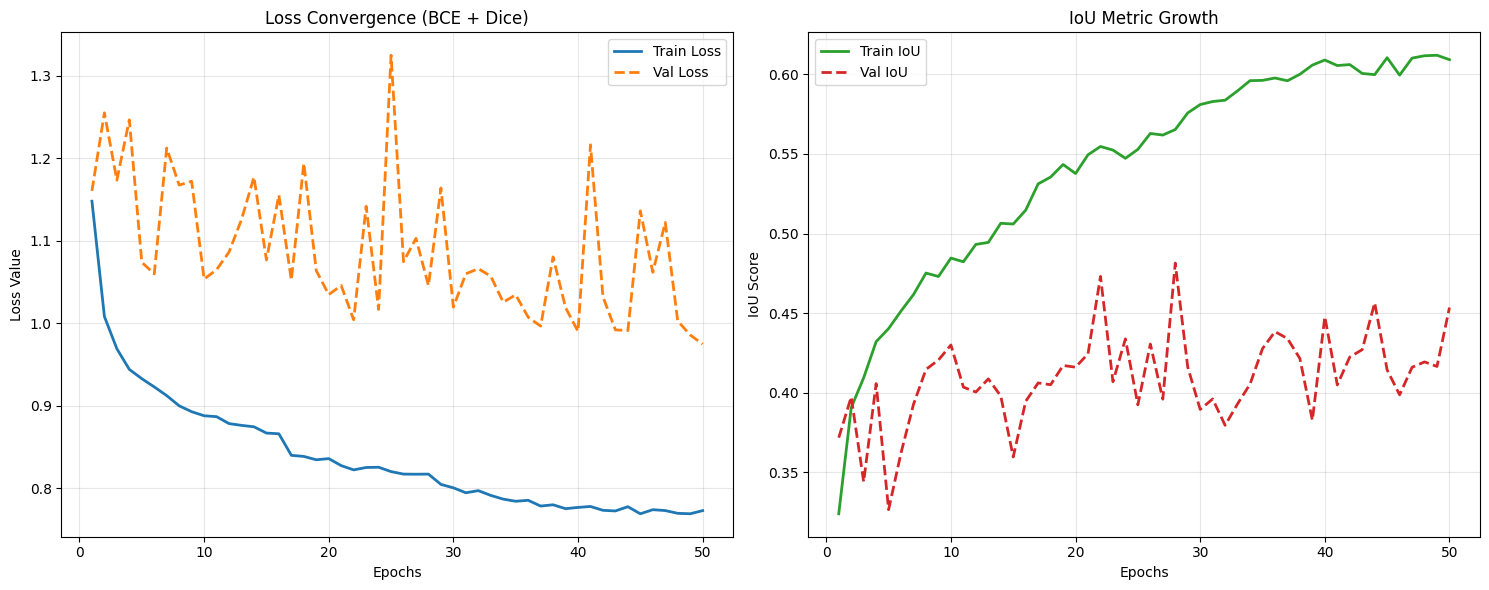

In [7]:
# Retrieve history from your dictionary
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(15, 6))

# Plot 1: Loss (BCE + Dice)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='#1f77b4', linewidth=2)
plt.plot(epochs_range, history['val_loss'], label='Val Loss', color='#ff7f0e', linestyle='--', linewidth=2)
plt.title('Loss Convergence (BCE + Dice)')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(alpha=0.3)

# Plot 2: IoU Metric
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_iou'], label='Train IoU', color='#2ca02c', linewidth=2)
plt.plot(epochs_range, history['val_iou'], label='Val IoU', color='#d62728', linestyle='--', linewidth=2)
plt.title('IoU Metric Growth')
plt.xlabel('Epochs')
plt.ylabel('IoU Score')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
import json

# Define the filename
history_filename = "m3_training_history_.json"

# Save history dictionary to a JSON file
with open(history_filename, 'w') as f:
    json.dump(history, f)

print(f"✅ Training history successfully saved to {history_filename}")

# --- HOW TO LOAD IT LATER ---
# with open(history_filename, 'r') as f:
#     loaded_history = json.load(f)

✅ Training history successfully saved to m3_training_history_.json


In [9]:
torch.save( model,"m3_full_attention_unet.pt")